# Feature Engineering 

In [1]:
import pandas as pd 

# Load the dataset from a CSV file
try:
    df = pd.read_csv('data/Telco-Customer-Churn.csv')
    print("Data loaded successfully!")
    print("First 5 rows of the dataset:")
    print(df.head())
except FileNotFoundError:
    print("Dataset file not found. Please download 'Telco-Customer-Churn.csv' from Kaggle and place it in the correct directory.")

Data loaded successfully!
First 5 rows of the dataset:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechS

In [2]:
# --- Feature Engineering Steps ---

# Ensure TotalCharges is numeric (it was object in the raw CSV)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

# Define the target and columns we DON'T want to one-hot encode
target_col = 'Churn'        # original column in the dataframe
id_col = 'customerID'      # don't one-hot encode IDs

# Select categorical columns but exclude the target and customerID
categorical_cols = df.select_dtypes(include=['object']).columns.drop([target_col, id_col])

# Apply one-hot encoding to only the selected categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
# drop_first=True helps avoid multicollinearity by dropping one category per feature

print("\nData after one-hot encoding:")
print(df_encoded.head())

# Separate features (X) and target (y)
# Drop id_col and the original target column from X (target remains in df)
X = df_encoded.drop([id_col, target_col], axis=1)
y = df[target_col].map({'Yes': 1, 'No': 0})  # convert target to binary



Data after one-hot encoding:
   customerID  SeniorCitizen  tenure  MonthlyCharges  TotalCharges Churn  \
0  7590-VHVEG              0       1           29.85         29.85    No   
1  5575-GNVDE              0      34           56.95       1889.50    No   
2  3668-QPYBK              0       2           53.85        108.15   Yes   
3  7795-CFOCW              0      45           42.30       1840.75    No   
4  9237-HQITU              0       2           70.70        151.65   Yes   

   gender_Male  Partner_Yes  Dependents_Yes  PhoneService_Yes  ...  \
0        False         True           False             False  ...   
1         True        False           False              True  ...   
2         True        False           False              True  ...   
3         True        False           False             False  ...   
4        False        False           False              True  ...   

   StreamingTV_No internet service  StreamingTV_Yes  \
0                            False   

/var/folders/30/klqc5hsj1dx7z3k9v9g6cbh40000gn/T/ipykernel_13368/111709446.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


# Fit Model 

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# --- Model Fitting Steps ---

# 1. Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# stratify=y ensures that the churn proportion is the same in both train and test sets.

# 2. Scale numerical features
# Scaling prevents features with large values (like TotalCharges) from dominating the model.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) # Use the same scaler fitted on the training data

# 3. Initialize and train (fit) the model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

print("\nLogistic Regression model fitted successfully!")


Logistic Regression model fitted successfully!


# Test Model 


Model Accuracy: 0.8070

Confusion Matrix:


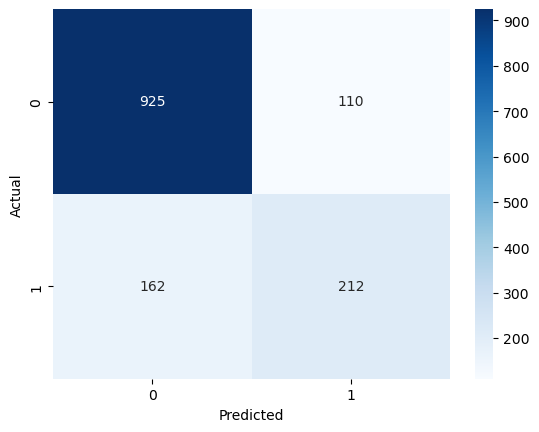


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [6]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# --- Model Testing Steps ---

# 1. Make predictions on the test set
y_pred = log_reg.predict(X_test)

# 2. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.4f}")

# 3. View the Confusion Matrix
# It shows True Positives, True Negatives, False Positives, and False Negatives.
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 4. View the Classification Report
# It provides precision, recall, and F1-score.
# - Precision: Of all churn predictions, how many were correct?
# - Recall: Of all actual churners, how many did we identify?
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Tune Model

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# --- Model Tuning Steps ---

# 1. Set up the parameter grid for GridSearchCV
# These are the hyperparameters we want to test.
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced'] # Important for imbalanced datasets
}

# 2. Initialize the RandomForest model and GridSearchCV
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, scoring='recall')
# cv=3 means 3-fold cross-validation. n_jobs=-1 uses all available CPU cores.

# 3. Fit GridSearchCV to find the best model
print("\nTuning RandomForest model with GridSearchCV... (This may take a moment)")
grid_search.fit(X_train, y_train)

# 4. Get the best model
best_rf = grid_search.best_estimator_
print(f"\nBest Parameters found: {grid_search.best_params_}")

# 5. Evaluate the tuned model
y_pred_tuned = best_rf.predict(X_test)
print("\nClassification Report for Tuned RandomForest Model:")
print(classification_report(y_test, y_pred_tuned))


Tuning RandomForest model with GridSearchCV... (This may take a moment)

Best Parameters found: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

Classification Report for Tuned RandomForest Model:
              precision    recall  f1-score   support

           0       0.89      0.77      0.83      1035
           1       0.54      0.75      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



Exception ignored in: <function ResourceTracker.__del__ at 0x1210a5c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1070a1c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105461c60>
Traceback (most recent call last

# Deploy Model

In [8]:
import joblib

# --- Model Deployment Steps ---

# 1. Save the trained model and the scaler to disk
joblib.dump(best_rf, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("\nTuned model and scaler have been saved.")

# --- Example of loading and using the model ---
# This part would be in your application code.
print("\n--- Simulating a real-time prediction ---")

# Load the model and scaler
loaded_model = joblib.load('churn_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

# Example: A new customer's data (must have the same structure as the training data)
# This would come from a web form or an API request.
# We create a dictionary and then a DataFrame for one customer.
new_customer_data = {
    'gender_Male': [1], 'SeniorCitizen': [0], 'Partner_Yes': [0], 'Dependents_Yes': [0],
    'tenure': [5], 'PhoneService_Yes': [1], 'MultipleLines_Yes': [0],
    'InternetService_Fiber optic': [1], 'InternetService_No': [0],
    'OnlineSecurity_No': [0], 'OnlineSecurity_Yes': [0],
    'OnlineBackup_No': [0], 'OnlineBackup_Yes': [0], 'DeviceProtection_No': [0],
    'DeviceProtection_Yes': [0], 'TechSupport_No': [0], 'TechSupport_Yes': [0],
    'StreamingTV_No': [0], 'StreamingTV_Yes': [0], 'StreamingMovies_No': [0],
    'StreamingMovies_Yes': [0], 'Contract_One year': [0], 'Contract_Two year': [0],
    'PaperlessBilling_Yes': [1], 'PaymentMethod_Electronic check': [1],
    'PaymentMethod_Mailed check': [0], 'PaymentMethod_Credit card (automatic)': [0],
    'MonthlyCharges': [75.50], 'TotalCharges': [350.50]
}

# Ensure all columns from the training set are present
new_customer_df = pd.DataFrame(new_customer_data)
all_cols = X.columns
for col in all_cols:
    if col not in new_customer_df.columns:
        new_customer_df[col] = 0
new_customer_df = new_customer_df[all_cols] # Ensure column order is the same

# Scale the data and make a prediction
new_customer_scaled = loaded_scaler.transform(new_customer_df)
prediction = loaded_model.predict(new_customer_scaled)
prediction_proba = loaded_model.predict_proba(new_customer_scaled)

print(f"Prediction (0=No Churn, 1=Churn): {prediction[0]}")
print(f"Churn Probability: {prediction_proba[0][1]:.2f}")

if prediction[0] == 1:
    print("Action: This customer is at high risk of churning. Escalate to the retention team.")
else:
    print("Action: This customer has a low churn risk.")


Tuned model and scaler have been saved.

--- Simulating a real-time prediction ---
Prediction (0=No Churn, 1=Churn): 1
Churn Probability: 0.83
Action: This customer is at high risk of churning. Escalate to the retention team.
